# 🚀 Transformers Básico - Seu Primeiro Contato com LLMs

**Objetivo:** Entender a arquitetura Transformer na prática

## 1. Introdução aos Modelos de Linguagem

### O que são LLMs?
Large Language Models (LLMs) são modelos de deep learning treinados em grandes quantidades de texto.

### Por que Transformers?
- Revolucionaram o NLP em 2017
- Permitem processamento paralelo
- Capturam dependências de longo alcance
- Base de GPT, BERT, T5, LLaMA, etc.

## Importações básicas

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

print(f"PyTorch versão: {torch.__version__}")
print(f"GPU disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memória GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch versão: 2.3.1+cu118
GPU disponível: True
GPU: NVIDIA GeForce 930M
Memória GPU: 2.15 GB


## 2. Arquitetura Transformer (Visão Simplificada)

In [10]:
#┌─────────────────────────────────────┐  
#│ TRANSFORMER                         │  
#├─────────────────────────────────────┤  
#│ Encoder:         │ Decoder:         │  
#│ • Self-Attention │ • Masked Attn    │  
#│ • Feed Forward   │ • Cross-Attn     │  
#│ • Norm + Residual│ • Feed Forward   │  
#└─────────────────────────────────────┘  

# Implementação didática de Self-Attention

In [2]:
class SimpleSelfAttention(nn.Module):
    def __init__(self, embed_size):
        super(SimpleSelfAttention, self).__init__()
        self.embed_size = embed_size
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, x):
        # x shape: [batch_size, seq_length, embed_size]
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.embed_size ** 0.5)
        attention = self.softmax(scores)
        
        # Apply attention to values
        out = torch.matmul(attention, V)
        return out, attention

## 3. Testando nossa implementação

Input shape: torch.Size([2, 5, 4])
Output shape: torch.Size([2, 5, 4])
Attention weights shape: torch.Size([2, 5, 5])


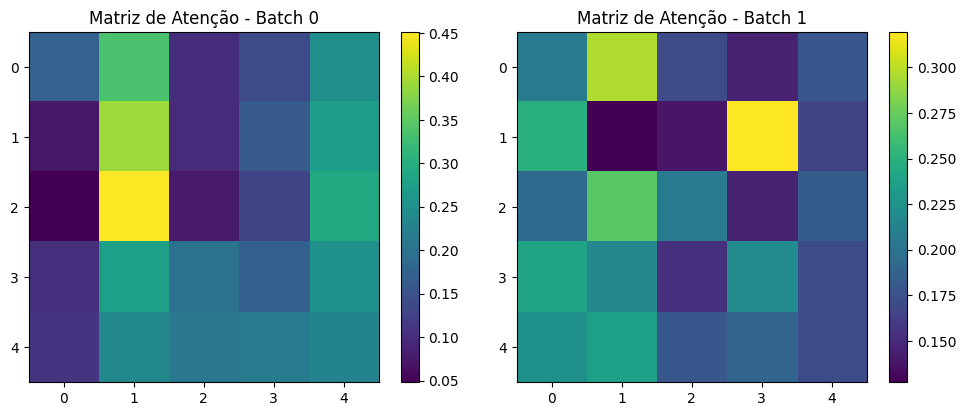

In [4]:
# Criando dados de exemplo
batch_size = 2
seq_length = 5
embed_size = 4

# Texto simulado: "O gato preto corre rápido"
x = torch.randn(batch_size, seq_length, embed_size)
print(f"Input shape: {x.shape}")

# Instanciando nosso módulo
attention = SimpleSelfAttention(embed_size)

# Forward pass
output, attn_weights = attention(x)
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

# Visualizando pesos de atenção
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(attn_weights[0].detach().numpy(), cmap='viridis')
plt.title("Matriz de Atenção - Batch 0")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(attn_weights[1].detach().numpy(), cmap='viridis')
plt.title("Matriz de Atenção - Batch 1")
plt.colorbar()
plt.tight_layout()
plt.show()

## 4. Usando Transformers Prontos (HuggingFace)

In [5]:
# Carregando um modelo pequeno (ideal para sua GPU de 2GB)
model_name = "microsoft/phi-2"  # 2.7B parâmetros

print(f"\nCarregando modelo: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# Texto de exemplo
text = "A inteligência artificial é"
inputs = tokenizer(text, return_tensors="pt")

print(f"Tokens: {inputs['input_ids']}")
print(f"Tokens decodificados: {tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])}")


Carregando modelo: microsoft/phi-2


C:\Users\pcwin\anaconda3\envs\esp_ai\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Tokens: tensor([[   32, 33649,   328, 25792, 10782,   544, 11666, 38251]])
Tokens decodificados: ['A', 'Ġintel', 'ig', 'Ãª', 'nc', 'ia', 'Ġartificial', 'ĠÃ©']


## 5. Experimentos Práticos

In [6]:
# Experimento 1: Como diferentes palavras são tokenizadas
texts = [
    "Olá, como vai você?",
    "Artificial Intelligence is amazing!",
    "O artigo 5º da Constituição Federal",
    "import torch\nmodel = nn.Transformer()"
]

print("Tokenização de diferentes textos:")
for text in texts:
    tokens = tokenizer.tokenize(text)
    print(f"\nTexto: {text[:50]}...")
    print(f"Tokens: {tokens[:10]}...")  # Mostra apenas primeiros 10
    print(f"Número de tokens: {len(tokens)}")

# %%
# Experimento 2: Atenção em frases jurídicas (seu nicho!)
juridic_text = "O artigo 5º da Constituição Federal garante o direito à propriedade."
tokens = tokenizer.tokenize(juridic_text)
print(f"\nTexto jurídico: {juridic_text}")
print(f"Tokens: {tokens}")
print(f"Número de tokens: {len(tokens)}")

# Verificando tokens especiais
print(f"\nToken especial [CLS]: {tokenizer.cls_token}")
print(f"Token especial [SEP]: {tokenizer.sep_token}")
print(f"Token especial [PAD]: {tokenizer.pad_token}")

Tokenização de diferentes textos:

Texto: Olá, como vai você?...
Tokens: ['Ol', 'Ã¡', ',', 'Ġcom', 'o', 'Ġv', 'ai', 'Ġvoc', 'Ãª', '?']...
Número de tokens: 10

Texto: Artificial Intelligence is amazing!...
Tokens: ['Art', 'ificial', 'ĠIntelligence', 'Ġis', 'Ġamazing', '!']...
Número de tokens: 6

Texto: O artigo 5º da Constituição Federal...
Tokens: ['O', 'Ġart', 'igo', 'Ġ5', 'Âº', 'Ġda', 'ĠConst', 'it', 'ui', 'Ã§']...
Número de tokens: 12

Texto: import torch
model = nn.Transformer()...
Tokens: ['import', 'Ġtorch', 'Ċ', 'model', 'Ġ=', 'Ġn', 'n', '.', 'Trans', 'former']...
Número de tokens: 11

Texto jurídico: O artigo 5º da Constituição Federal garante o direito à propriedade.
Tokens: ['O', 'Ġart', 'igo', 'Ġ5', 'Âº', 'Ġda', 'ĠConst', 'it', 'ui', 'Ã§', 'Ã£o', 'ĠFederal', 'Ġg', 'arant', 'e', 'Ġo', 'Ġdire', 'ito', 'ĠÃł', 'Ġprop', 'ried', 'ade', '.']
Número de tokens: 23

Token especial [CLS]: None
Token especial [SEP]: None
Token especial [PAD]: None


## 6. Exercícios Práticos

In [7]:
# Exercício 1: Implemente Multi-Head Attention
class SimpleMultiHeadAttention(nn.Module):
    def __init__(self, embed_size, num_heads):
        super(SimpleMultiHeadAttention, self).__init__()
        assert embed_size % num_heads == 0, "Embed size must be divisible by num_heads"
        
        self.embed_size = embed_size
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads
        
        # TO DO: Implementar multi-head attention
        # Dica: Divida os embeddings em múltiplas "cabeças"
        
    def forward(self, x):
        # TO DO: Implementar forward pass
        pass

# Teste seu código aqui
# multi_head_attn = SimpleMultiHeadAttention(embed_size=8, num_heads=2)
# output = multi_head_attn(torch.randn(1, 4, 8))

In [9]:
# Verificação final
print("\n" + "="*60)
print("✅ AMBIENTE ESTÁ PRONTO PARA LLMs!")
print("="*60)

print(f"\nRecursos disponíveis:")
print(f"- GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"- Memória: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB" if torch.cuda.is_available() else "- Memória: RAM")
print(f"- PyTorch: {torch.__version__}")
print(f"- Transformers: 4.40.1")


✅ AMBIENTE ESTÁ PRONTO PARA LLMs!

Recursos disponíveis:
- GPU: NVIDIA GeForce 930M
- Memória: 2.15 GB
- PyTorch: 2.3.1+cu118
- Transformers: 4.40.1
